### 词云

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer # 用于将文本文档集合转换为 TF-IDF 特征矩阵
import numpy as np

def CalculateTFIDF(x): # x 必须是字符串

    tfidf = TfidfVectorizer() # 计算 x 的 TF-IDF 矩阵: 创建一个 TfidfVectorizer 对象实例
    weight = tfidf.fit_transform(x).toarray() # 训练拟合转化为numpy
    word = tfidf.get_feature_names_out() # 得到不重复的关键词

    print(word) 
    
    # weight文档数目: 打印出词汇表的大小 (len(word)) 和文档的数量 (len(weight)，即 TF-IDF 矩阵的行数)
    print('大小是', len(word), ' ', len(weight))

    # 计算每个词的最大 TF-IDF 权重
    maxweight = np.max(weight,axis = 0)# 这是一个一维数组: axis = 0 按列计算

    # 构建词汇和最大权重的字典
    word_fre = {word[j] : maxweight[j] for j in range(len(word))}

    # 按权重排序 (降序)
    sorted_word_fre = sorted(word_fre.items(), key = lambda kv:(-kv[1], kv[0]))

    print(sorted_word_fre)
    return word_fre

In [2]:
import pandas as pd
import re
import jieba

# 停用词列表函数
def GetStopWordsList():
    stopwords = [line.strip() for line in open('cn_stopwords.txt',encoding = 'UTF-8').readlines()]
    return stopwords

# 匹配汉字函数
def MatchChinese(text):
    # 匹配所有汉字字符
    chinese_pattern = r'[\u4e00-\u9fa5]+' # \u4e00-\u9fa5 用于表示Unicode中常见汉字的范围
    # 查找所有汉字
    chinese_text = re.findall(chinese_pattern,text)
    # re.findall(chinese_pattern, text)：在输入文本 text 中查找所有符合 chinese_pattern 模式的子串，并返回一个列表 chinese_text
    return chinese_text

# 文本处理函数 (列表转字符串) : list->string
def ProcessWords(sentence):
    sentence_list = MatchChinese(sentence)
    sentence = '' # 初始化一个空字符串 sentence，用于存放连接后的结果
    for sentence_l in sentence_list:
        sentence += sentence_l
    return sentence

# 对句子进行中文分词
def SegDepart(sentence):
    # 对文档中的每一行进行中文分词
    sentence_depart = jieba.lcut(str(sentence).strip())
    return sentence_depart

# 去除停用词
def RemoveStopWords(sentence_list,stopwords_list):
    out_list = [word for word in sentence_list if word not in stopwords_list]
    return out_list


# 主数据处理流程函数
def ProcessData(filepath):
  
    data = pd.read_excel(filepath)

    text = []
    stop_list = GetStopWordsList()
    for i in range(len(data)):
        str_row = data.iloc[i,3] # 评论行
        # 移除不合适的字符,只留下中文字符串
        str_row = ProcessWords(str_row)
        # 分词
        str_row = SegDepart(str_row)
        # 移除停用词
        line_without = RemoveStopWords(str_row,stop_list)
        # 移除特定的停用词
        #stop_listBaidu = getStopwordsWeiboList()
        #line_without = moveStopwords(line_without, stop_listBaidu)
        line_str = ' '.join(line_without)
        text.append(line_str)

    return text

In [3]:
x = ProcessData('weibo_data_miansan.xlsx')
word_fre = CalculateTFIDF(x)

Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/hx/vrwsgqgx7bncbt28n44f0b540000gn/T/jieba.cache
Loading model cost 0.951 seconds.
Prefix dict has been built successfully.


['一上午' '一件' '一会儿回' '一体' '一圈' '一层' '一帧' '一座座' '一把' '一支' '一晃' '一条' '一棉'
 '一棵树上吊死' '一点一滴' '一点点' '一眼' '一趟' '三专' '三件套' '三刷' '三厂' '三天' '三张' '三明治' '三生'
 '三等' '三老' '三部' '上去' '上合' '上帝' '上档次' '上次' '上百年' '下刚' '下回' '下次' '下课' '下雨天'
 '不吃' '不甘' '不甜' '不知' '不错' '专场' '世事' '世纪' '业态' '丛台区' '东岸' '东西' '两大' '两天'
 '两益' '个头' '个性' '中介' '中介费' '中午' '中华' '中棉' '中老年' '中锋' '丰富' '主力' '主办' '主打'
 '主要' '主题' '举杯' '久违' '之店' '之感' '之旅' '习惯' '买件' '二十五' '二多里' '二踢脚' '云朵' '互动'
 '五大' '五福' '交融' '产业' '享受' '亲切' '人人' '人民政府' '人生' '人真' '人请' '仅个' '今日' '今晚报'
 '今非昔比' '介绍' '以购' '价值' '任务' '企业' '休息日' '休闲' '会展中心' '伟大' '位于' '低调' '体育'
 '体育局' '体育部' '体验' '作业' '作美' '便宜' '信念' '借图' '值得' '假期' '做姓' '停下' '停车费' '健身'
 '偶尔' '偶遇' '储存' '像模像样' '儿子' '充满' '充电' '光泽' '光里' '免费' '入冬' '全枚' '八一队' '八卦'
 '八小时' '公交' '公司' '公园' '六年' '六点半' '共同' '具体' '再办' '再普' '冷萃' '准备' '准确' '减肥'
 '出发' '出小卡' '出笼' '出门' '分钟' '切肤' '刚才' '创业' '创作' '创建' '创意' '初体验' '初心' '利用'
 '到期' '券月' '前往' '劳动' '包书皮' '包出' '包未' '包赠' '包邮送' '包饭' '北京' '北洋' '区金湾' '十二'
 '十五' '十六' '十几斤' '十周年' '十月' '千亩' '午休' '午后' '午餐' '

In [4]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from matplotlib import font_manager

def DrawWordCloud(wordsDict,name):
    """
    生成词云。
    1.配置WordCloud。2.plt进行显示
    :return:
    """

    # 设置字体
    font_path = 'SIMHEI.TTF'

    # 设置词云属性
    wc = WordCloud(font_path = font_path,           # 设置字体,若是有中文的话，这句代码必须添加，不然会出现方框，不出现汉字
                   background_color = 'white',      # 背景颜色
                   max_words = 100,                 # 词云显示的最大词数
                   random_state = 30,               # 设置有多少种随机生成状态，即有多少种配色方案
                   width = 800,                     # 输出的画布宽度
                   height = 600)                    # 输出的画布高度

    # 根据频率生成词云
    wc.generate_from_frequencies(wordsDict)

    # 显示图片
    plt.figure()
    plt.imshow(wc)
    plt.axis('off')
    plt.show()
    
    # 保存到本地
    wc.to_file(f'{name}词云.jpg')

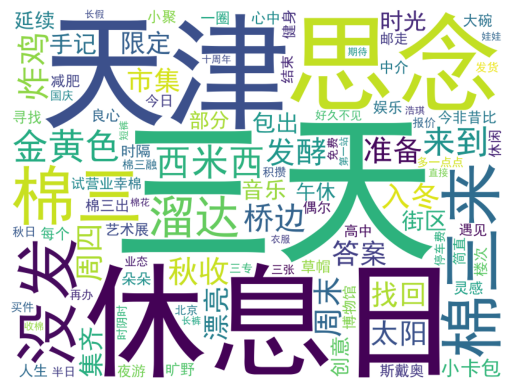

In [5]:
DrawWordCloud(word_fre,'weibo_棉三')

### 情感打分

In [1]:
import pandas as pd

data = pd.read_excel('weibo_data_miansan.xlsx')
data.head()

,关键词,发博用户,发博时间,博文内容
0,棉三,溜溜哥,"07月07日,22:43",棉三试营业小聚“你心中的1087X是什么？”​
1,棉三,安然_0809,"10月04日,21:13",久违了，与儿子的单独“约会”偶遇坐落于“棉三创意街区”里的LOPI，咖啡厅与香氛家居集合店为...
2,棉三,烜烜熊-minoz,"09月04日,23:07",是开学周啊，可真忙活。大哥忙着包书皮，我负责做姓名牌。庆幸皮总只用一上午的时间就适应了一年级...
3,棉三,神魂永恒,"08月17日,19:45",棉三部这一套有无数的皮带，可以去罗德岛报道了 ​
4,棉三,太阳探店Plus,"03月24日,08:00",石家庄老牌炸鸡店，开了30年的棉三炸鸡，这么多年只卖手枪腿​


In [2]:
comments = [data.iloc[i,3] for i in range(len(data))]
comments

['棉三试营业小聚“你心中的1087X是什么？”\u200b',
 '久违了，与儿子的单独“约会”偶遇坐落于“棉三创意街区”里的LOPI，咖啡厅与香氛家居集合店为一体的特色店铺，低调且高级，香氛及家居礼品深得我心，收了一支绿薄荷香型的护手霜，虽小贵，但是它所带来的情绪价值，却让人觉得贵得值得。因为娃着急要回家，遗憾这次未能喝到咖啡，留给下次吧。生 \u200b',
 '是开学周啊，可真忙活。大哥忙着包书皮，我负责做姓名牌。庆幸皮总只用一上午的时间就适应了一年级新生活，没有走错班，找得到洗手间，能叫出老师的姓名，我已经非常非常知足了，望未来六年“旅途”愉快！龙湖公园新开的咖啡店和棉三公园新开的无中友生都还不错，就是还留存一点点装修的味道 \u200b',
 '棉三部这一套有无数的皮带，可以去罗德岛报道了 \u200b',
 '石家庄老牌炸鸡店，开了30年的棉三炸鸡，这么多年只卖手枪腿\u200b',
 '【棉三厂房大变身，创意街区潮翻天！】漫步棉三，解锁工业文艺混搭新风尚！\u200b',
 '棉三里面咋啥都没了 \u200b',
 '棉三，一个天津人耳熟能详的名字，曾在古老的年代首创“八小时工作制”，成为中国棉纺织业的标杆，如今更成了年轻人雕刻梦想的基地。今天要讲的，就是这座老厂的三生故事。\u200b',
 '11月15，和GR YARIS一起搞个活动，具体可以gz号看，欢迎大家来玩哟！礼品多多！\u200b',
 '棉三来过咯 \u200b',
 '棉三创意街区，天津第三棉纺织厂，简称“棉三”，位于天津市河东区，是中国近代工业发展的重要遗迹之一。20世纪20年代，裕大纱厂和宝成纱厂在北洋时期由民族资本家及海归留学人员创建。1925年到1936年，这两大纱厂相继被日资企业大福公司占领吞并。1945年，棉三改名为中国纺织建设股份有限公司。1950年 \u200b',
 '豹纹kt云朵棉版本我们做的是三件套哦就是一件短袖配一条短裤➕一条长裤长裤是图3那样的短裤是图4那样的 \u200b',
 '为喝这杯咖啡晚高峰公交转单车将近两小时x有时候觉得我也太不嫌麻烦JPG棉三里面挺漂亮的，外面白天就像个工地，晚上看更像了🏳️但这杯真的很好喝！西柚味和橙子味很浓\u200b',
 '上合蓝☁️但也太晒了被晒懵了挑战了从单位到棉三单程9分钟\u200b',
 '许久没有出门溜达，

In [4]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# 加载预训练模型
tokenizer = BertTokenizer.from_pretrained('uer/roberta-base-finetuned-jd-binary-chinese')
model = BertForSequenceClassification.from_pretrained('uer/roberta-base-finetuned-jd-binary-chinese') 

# 设定模型为评估模式
model.eval()
# 将模型设置为评估模式 (eval())。这会关闭训练时特有的功能（如 Dropout、Batch Normalization 层的更新），确保模型在推理时行为稳定且输出确定

# 处理每条评论并进行推理
scores= []
for comment in comments:
    inputs = tokenizer(comment,
                       padding = True,
                       truncation = True,
                       max_length = 512,
                       return_tensors = 'pt')
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        # 从 outputs 中提取出 logits，这是模型对于每个类别的原始得分。在二分类模型中，logits 是一个包含两个数值的向量，对应正面和负面情绪的原始得分。
        
        # softmax 函数将 logits 转换为概率值，使得输出结果的所有类别的概率之和为 1。
        prob = torch.nn.functional.softmax(logits,dim = -1) # 计算正/负面概率
        scores.append(prob[0][1].item()) # 取正面情绪的概率
        # prob[0]: 由于输入是一个批次（Batch）大小为 1 的张量，prob[0] 取出了这一个样本的概率向量。
        # [1]: 提取向量中索引为 1 的概率值。根据模型约定，这个索引通常代表正面情绪的概率 $P(\text{正面})$。
        # .item(): 将 PyTorch 张量中的数值提取为标准 Python 浮点数，并存入 scores 列表。

# 统计正面和负面评论数量
positive = []
negative = [] 
for score in scores:
    if (score > 0.5):
        positive.append(score)
    else:
        negative.append(score)

print(scores)

# 计算整体情感得分（0-1 之间，越高越正面）
average_score = sum(scores)/len(scores)
print(f"整体情感得分: {average_score:.2f}")

/opt/anaconda3/envs/py39/lib/python3.9/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[0.6294068098068237, 0.9889283180236816, 0.9878026843070984, 0.9851735830307007, 0.2999397814273834, 0.8749376535415649, 0.12452400475740433, 0.9879820942878723, 0.9814373254776001, 0.6299946308135986, 0.9471606612205505, 0.2770439386367798, 0.9893324375152588, 0.5720778703689575, 0.9937297105789185, 0.8199949860572815, 0.7730315923690796, 0.9896734952926636, 0.9326225519180298, 0.9610815644264221, 0.9355891942977905, 0.9699137806892395, 0.9073916673660278, 0.9849486947059631, 0.9884266257286072, 0.23998171091079712, 0.8263367414474487, 0.9889743328094482, 0.693117618560791, 0.977836012840271, 0.940085768699646, 0.4770795404911041, 0.8872051239013672, 0.8235099911689758, 0.5810574293136597, 0.987508237361908, 0.7206382155418396, 0.945941686630249, 0.9763844609260559, 0.9113081693649292, 0.888617992401123, 0.89714115858078, 0.4570622444152832, 0.8662968277931213, 0.46514055132865906, 0.5579779148101807, 0.944396436214447, 0.9503514766693115, 0.9051012992858887, 0.9872727990150452, 0.838

In [5]:
data['emotion_scores'] = scores
data.head()

,关键词,发博用户,发博时间,博文内容,emotion_scores
0,棉三,溜溜哥,"07月07日,22:43",棉三试营业小聚“你心中的1087X是什么？”​,0.629407
1,棉三,安然_0809,"10月04日,21:13",久违了，与儿子的单独“约会”偶遇坐落于“棉三创意街区”里的LOPI，咖啡厅与香氛家居集合店为...,0.988928
2,棉三,烜烜熊-minoz,"09月04日,23:07",是开学周啊，可真忙活。大哥忙着包书皮，我负责做姓名牌。庆幸皮总只用一上午的时间就适应了一年级...,0.987803
3,棉三,神魂永恒,"08月17日,19:45",棉三部这一套有无数的皮带，可以去罗德岛报道了 ​,0.985174
4,棉三,太阳探店Plus,"03月24日,08:00",石家庄老牌炸鸡店，开了30年的棉三炸鸡，这么多年只卖手枪腿​,0.299940


In [6]:
try:
    data.to_excel('weibo_emotion.xlsx', index=False)
    print(f"🎉 结果已成功保存到新的文件: {'weibo_emotion.xlsx'}")
    print("DataFrame 前5行示例:")
    print(data.head())
except Exception as e:
    print(f"❌ 错误：保存 Excel 文件失败。错误信息: {e}")

🎉 结果已成功保存到新的文件: weibo_emotion.xlsx
DataFrame 前5行示例:
  关键词       发博用户          发博时间  \
0  棉三        溜溜哥  07月07日,22:43   
1  棉三    安然_0809  10月04日,21:13   
2  棉三  烜烜熊-minoz  09月04日,23:07   
3  棉三       神魂永恒  08月17日,19:45   
4  棉三   太阳探店Plus  03月24日,08:00   

                                                博文内容  emotion_scores  
0                            棉三试营业小聚“你心中的1087X是什么？”​        0.629407  
1  久违了，与儿子的单独“约会”偶遇坐落于“棉三创意街区”里的LOPI，咖啡厅与香氛家居集合店为...        0.988928  
2  是开学周啊，可真忙活。大哥忙着包书皮，我负责做姓名牌。庆幸皮总只用一上午的时间就适应了一年级...        0.987803  
3                           棉三部这一套有无数的皮带，可以去罗德岛报道了 ​        0.985174  
4                     石家庄老牌炸鸡店，开了30年的棉三炸鸡，这么多年只卖手枪腿​        0.299940  


### 聚类

In [28]:
import pandas as pd
import re 
import jieba

# 匹配汉字(去掉数字符号emoji)
def match_chinese(text):
    chinese_pattern = r'[\u4e00-\u9fa5]+' # \u4e00-\u9fa5 用于表示Unicode中常见汉字的范围
    chinese_text = re.findall(chinese_pattern,text) # 在输入文本 text 中查找所有符合 chinese_pattern 模式的子串，并返回一个列表 chinese_text
    return chinese_text

# list -> string
def processWords(sentence):
    sentence_list = match_chinese(sentence)
    sentence = ''
    for sentence_l in sentence_list:
        sentence += sentence_l
    return sentence

# 分词
def segDepart(sentence):
    sentence_depart = jieba.lcut(str(sentence).strip())
    return sentence_depart
    
# 停用词表1
def getStopwordsList():
    stopwords = [line.strip() for line in open('cn_stopwords.txt',encoding = 'UTF-8').readlines()]
    return stopwords

# 停用词表2
def getStopwordsWeiboList():
    stopwords = [line.strip() for line in open('weibo_stopwords.txt',encoding = 'UTF-8').readlines()]
    return stopwords

# 去掉停用词
def moveStopwords(sentence_list,stopwords_list):
    out_list = [word for word in sentence_list if word not in stopwords_list]
    return out_list
    
# final
def ProcessData(filepath):

    data = pd.read_excel(filepath)

    text = []
    stop_list = getStopwordsList()

    for i in range(len(data)):
        str_row = data.iloc[i,3]
        
        # 移除不合适字符
        str_row = processWords(str_row)
        # 分词
        str_row = segDepart(str_row)
        # 停用词表
        line_without = moveStopwords(str_row,stop_list)
        
        # 移除特定的停用词
        stop_list_weibo = getStopwordsWeiboList()
        line_without = moveStopwords(line_without, stop_list_weibo)

        text.append(line_without)

    return text

In [29]:
processed_docs = ProcessData('weibo_data_miansan.xlsx')
processed_docs

[['试营业', '小聚', '心中'],
 ['久违',
  '儿子',
  '单独',
  '约会',
  '偶遇',
  '坐落于',
  '创意',
  '街区',
  '咖啡厅',
  '香氛',
  '家居',
  '集合',
  '店为',
  '一体',
  '特色',
  '店铺',
  '低调',
  '高级',
  '香氛',
  '家居',
  '礼品',
  '深得我心',
  '收',
  '一支',
  '绿',
  '薄荷香',
  '型',
  '护手霜',
  '虽小贵',
  '带来',
  '情绪',
  '价值',
  '贵得',
  '值得',
  '娃',
  '着急',
  '遗憾',
  '未能',
  '喝',
  '咖啡',
  '留给',
  '下次',
  '生'],
 ['周',
  '真',
  '忙活',
  '大哥',
  '忙',
  '包书皮',
  '负责',
  '做姓',
  '名牌',
  '庆幸',
  '皮',
  '总',
  '只用',
  '一上午',
  '时间',
  '适应',
  '新',
  '走',
  '错班',
  '找',
  '得到',
  '洗手间',
  '出',
  '姓名',
  '知足',
  '未来',
  '六年',
  '旅途愉快',
  '龙湖',
  '公园',
  '新开',
  '咖啡店',
  '棉',
  '三',
  '公园',
  '新开',
  '中',
  '友生',
  '不错',
  '留存',
  '一点点',
  '装修',
  '味道'],
 ['棉', '三部', '无数', '皮带', '罗德岛', '报道'],
 ['老牌', '炸鸡', '店开', '棉', '三', '炸鸡', '多年', '只卖', '手枪', '腿'],
 ['厂房', '大变身', '创意', '街区', '潮', '翻天', '漫步', '解锁', '工业', '文艺', '混', '搭', '新风尚'],
 ['没'],
 ['天津人',
  '耳熟能详',
  '名字',
  '古老',
  '年代',
  '首创',
  '八小时',
  '工作制',
  '成为',
  '棉纺织业',
  '标杆',
  '如今',
  

In [30]:
def LoadData(filepath):

    # 读取文件
    data = pd.read_excel(filepath)

    text = []

    for i in range(len(data)):
        str_row = data.iloc[i,3]
        
        # 移除不合适单词
        str_row = processWords(str_row)
        # 分词
        str_row = segDepart(str_row)
        # 停用词
        stop_list = getStopwordsList()
        line_without = moveStopwords(str_row,stop_list)

        # 移除特定的停用词
        stop_list_weibo = getStopwordsWeiboList()
        line_without = moveStopwords(line_without, stop_list_weibo)

        line_str = ' '.join(line_without)
        text.append(line_str)

    return text

In [31]:
# 1. 导入必要的库

from sklearn.feature_extraction.text import TfidfVectorizer # 导入 TfidfVectorizer，用于将文本数据转换为 TF-IDF (词频-逆文档频率) 向量。
from sklearn.preprocessing import Normalizer # 导入 Normalizer，用于归一化（L2范数归一化），确保向量具有单位长度。
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD # 导入 TruncatedSVD（截断奇异值分解），用于降维，尤其适用于稀疏矩阵（如 TF-IDF 矩阵）。
from sklearn.pipeline import make_pipeline 
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm # 导入 matplotlib.font_manager，用于指定中文字体，解决中文乱码问题。
from collections import Counter # 导入 Counter 类，用于高效地统计词语出现频率。
# %matplotlib inline # Jupyter 或 IPython 环境下的魔术命令，用于在代码单元格下方直接显示 Matplotlib 图表。
import seaborn as sns

# 2. 函数定义与参数 (getKmeans)

def getKmeans(filepath,name,n_clusters = 5,max_df = 0.5,min_df = 2,max_iter = 100,n_init = 1):
    """
    Perform KMeans clustering on text data and visualize the results in a pie chart.

    :param filepath: The path to the text data file
    :param name: A label for the clustering name (used in visualization and filename)
    :param n_clusters: The number of clusters for KMeans (default 5)
    :param max_df: 在文本中出现的“最大文档频率”。它指定了一个阈值，任何在超过 max_df 比例的文档中出现的词语都会被忽略。
    :param min_df: 在文本中出现的“最小文档频率”。它指定了一个阈值，只有在至少 min_df 文档中出现的词语才会被考虑。
    :param max_iter: 指定 KMeans 算法的最大迭代次数
    :param n_init: Number of initializations for KMeans
    """
    
    # 3. 数据加载与 TF-IDF 向量化

    # Load data (assuming a custom loadData function exists)
    data = LoadData(filepath)

    # 获得tf-idf向量
    vectorize_tfidf = TfidfVectorizer(max_df = max_df,min_df = min_df,use_idf = True)
    # 初始化 TF-IDF 向量化器，使用传入的 max_df 和 min_df 参数来过滤过于常见和过于罕见的词语。use_idf=True 确保启用 IDF 权重。
    X_tfidf = vectorize_tfidf.fit_transform(data)
    # 拟合 (学习词汇表和 IDF 权重) 并 转换 (将文本转换为稀疏矩阵形式的 TF-IDF 向量)。

    # 4. 降维与归一化 : 它通过 LSA (潜在语义分析) 提高聚类效果并加速计算
    
    # 使用SVD进行降维
    svd = TruncatedSVD(100) # 初始化 SVD 降维器，将特征维度从原始的词汇数量降至 100 维
    normalizer = Normalizer(copy = False) # 初始化归一化器，对降维后的向量进行归一化。copy=False 允许原地操作以节省内存。
    lsa = make_pipeline(svd,normalizer) # 创建一个 Pipeline，将 SVD 降维和 Normalizer 归一化步骤串联起来。
    X_tfidf_lsa = lsa.fit_transform(X_tfidf) # 将 TF-IDF 矩阵 X_tfidf 通过 LSA Pipeline 进行降维和归一化，得到最终用于聚类的矩阵。

    # 5. K-Means 聚类

    # 应用聚类
    # k-means++ ：初始化聚类中心的方法。是一种智能初始化方法，它通过选择一个远离已选择中心点的数据点作为新的中心来减少聚类收敛时的随机性。
    # max_iter 指定 KMeans 算法的最大迭代次数。即在没有收敛时，算法最多允许多少次更新聚类中心的位置。过小的 max_iter 可能导致算法没有完全收敛，过大的 max_iter 可能导致计算时间过长。
    # n_init: 指定算法运行的次数。每次运行都会随机初始化聚类中心，KMeans 会选择最佳的结果。多次运行有助于避免由于初始聚类中心选择不佳而导致的局部最优解。
    # verbose: 控制是否输出详细信息。设置为 True 时，算法运行过程中会输出每次迭代的信息；设置为 False 时，禁止输出信息。
    km = KMeans(n_clusters = n_clusters,
                init = 'k-means++',
                max_iter = max_iter,
                n_init = n_init,
                verbose = False)
    km_X_tfidf_lsa = km.fit(X_tfidf_lsa)

    # 6. 结果提取与主题词分析
    
    # 预测聚类 : 获取每个文档属于哪个聚类的标签。
    labels = km.predict(X_tfidf_lsa)

    # 统计聚类和每个对应的数目
    clusters = [[] for _ in range(n_clusters)] # 初始化一个列表，用于存储每个聚类下的文档索引。
    for idx,label in enumerate(labels):
        clusters[label].append(idx) # 遍历标签，将文档的原始索引 (idx) 添加到其对应的聚类列表 (label) 中。
    cluster_items = [len(cluster) for cluster in clusters] # 统计每个聚类中的文档数量。

    # 将聚类中心从降维后的空间映射回原始的TF-IDF特征空间
    original_space_centroids = svd.inverse_transform(km_X_tfidf_lsa.cluster_centers_) 
    # 将 K-Means 在 LSA 空间中找到的聚类中心（100维向量）反向映射回原始的 TF-IDF 特征空间（高维向量），以便进行主题解释。

    # 聚类中心中的每个元素按值排序。这里排序的是聚类中心向量中每个词的权重（重要性）
    order_centroids = original_space_centroids.argsort()[:,::-1]

    # 获取TF-IDF特征矩阵中每一列对应的词汇，即构建模型时所用的所有词汇
    terms = vectorize_tfidf.get_feature_names_out() # 获取 TF-IDF 向量化器学到的所有词语（即特征名称）。

    # 遍历每个聚类，提取其聚类中心向量中权重最高的前 3 个词语，用空格连接作为主题描述。
    tips = []
    for i in range(n_clusters):
        tip = ' '.join(terms[ind] for ind in order_centroids[i,:3]) # top3
        tips.append(tip)

    # 统计所有聚类中心的前3个关键词
    term_counts = Counter() # 初始化计数器。创建一个空的 Counter 对象，用于存储和统计词语的出现次数。

    for i in range(n_clusters):
        top_terms = [terms[ind] for ind in order_centroids[i,:3]]
        # 提取 Top 3 关键词。对于当前的第 $i$ 个聚类：* order_centroids[i, :3] 提取该聚类中心权重最高的前 3 个词语的索引。
        # terms[ind] 将这些索引映射回具体的词语字符串。* 结果 top_terms 是一个包含 3 个字符串的列表，例如 ['服务', '态度', '差']。
        term_counts.update(top_terms)
        # 更新计数。使用 Counter 的 .update() 方法，将 top_terms 列表中的词语添加到 term_counts 中，并自动增加每个词的计数
    print(term_counts)

    # 打印出现次数
    for term,count in term_counts.most_common():
        # .most_common() 方法会返回一个包含词语及其计数的列表，列表中的元素是 (term, count) 元组，并且默认按 count 降序排列。
        print(f"{term}: {count}")

    print("Cluster sizes:", cluster_items)
    print("Top terms per cluster:")
    for i, tip in enumerate(tips):
        print(f"Cluster {i}: {tip}")

    # 7. 饼图可视化
    
    # 指定 SimHei 字体路径
    font_path = 'SIMHEI.TTF'
    
    # 应用到 Matplotlib
    my_font = fm.FontProperties(fname=font_path)
    plt.rcParams['axes.unicode_minus'] = False  # 避免负号显示错误
    
    # 绘制饼状图
    plt.figure(figsize=(8, 6))  # 设置图表大小
    sns.set(palette = 'crest')
    plt.pie(
        cluster_items,
        labels=tips,  # 设置饼图标签
        autopct="(%1.1f%%)",  # 饼块内标签
        textprops={"fontproperties": my_font},  # 设置字体
    )

    plt.title(f"{name} 聚类饼状图", fontproperties=my_font)  # 指定字体

    # **先保存再显示**
    save_path = f"{name} 聚类分析饼状图.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")  # 高分辨率保存
    plt.show()  # 显示图像

Counter({'创意': 2, '街区': 2, '文艺': 1, '厂房': 1, '一圈': 1, '时光': 1, '炸鸡': 1, '粉丝': 1, '咖啡': 1, '河东': 1, '纱厂': 1, '世纪': 1, '棉纺织厂': 1})
创意: 2
街区: 2
文艺: 1
厂房: 1
一圈: 1
时光: 1
炸鸡: 1
粉丝: 1
咖啡: 1
河东: 1
纱厂: 1
世纪: 1
棉纺织厂: 1
Cluster sizes: [2, 9, 95, 2, 2]
Top terms per cluster:
Cluster 0: 文艺 厂房 一圈
Cluster 1: 创意 街区 时光
Cluster 2: 炸鸡 粉丝 咖啡
Cluster 3: 河东 街区 创意
Cluster 4: 纱厂 世纪 棉纺织厂


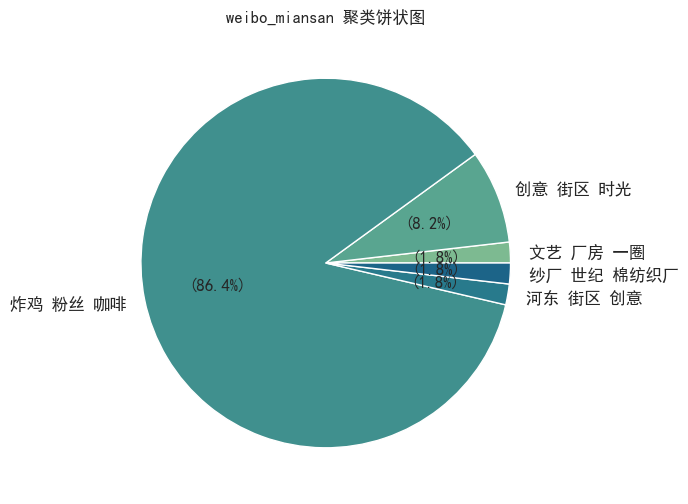

In [32]:
getKmeans('weibo_data_miansan.xlsx','weibo_miansan')